<h1 style="text-align: center;"> Reto III: Comparación de un modelo base de RNN-LSTM con diferentes inicializadores de pesos.  </h1>
<p align="center">
  <img src="https://cdn.prod.website-files.com/649475f4d573d5d9d1522659/649475f4d573d5d9d1522705_logo-track-ciencia.webp" alt="Logo Track Ciencia">
</p>

**Contexto del caso**

El caso de uso trata sobre un conjunto de datos de series de tiempo de consumo enérgetico y se busca aplicar LSTM.

**Objetivos del reto**

- Este reto busca que los alumnos experimenten con el problema del **vanishing gradient** comúnmente observado en redes neuronales recurrentes.

- Al utilizar el conjunto de datos de consumo energetico y, a medida que la serie de tiempo sea más profunda, el algoritmo clásico de SGD tendrá graves problemas, pues el gradiente en cada paso se desvanecerá.

- Sugerimos comenzar con una red recurrente LSTM como la vista en clase y comparar la función de costo, además de la norma de los gradientes en cada época, variando los hiperparámetros

**kernel_initializer**, 

**recurrent_initializer**. 

Para cada modelo utiliza los siguientes inicializadores de pesos respectivamente:

1. glorot_uniform: ("glorot_uniform", "orthogonal")
2. he_normal: ("he_normal", "he_normal")
3. orthogonal": ("orthogonal", "orthogonal")
4. random_normal: (tf.keras.initializers.RandomNormal(stddev=0.2), tf.keras.initializers.RandomNormal(stddev=0.2))

# Librerias

In [1]:
import pandas as pd
import numpy as np

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import layers, models, callbacks, optimizers, initializers
from tensorflow.keras.models import load_model


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

from pathlib import Path
import math


# Carga del conjunto de datos y pre-procesamiento

In [2]:
df_15min = pd.read_csv('/Users/danielml/Documents/Computational/Curso_Bourbaki/Math_Deep_Learning/Semana_3/1/LD2011_2014.txt',
                       sep = ';', parse_dates = [0], index_col=0, decimal=',', dtype=np.float64 
                    )

df_15min.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_15min.describe()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
count,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,...,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,3.970785,20.768480,2.918308,82.184490,37.240309,141.227385,4.521338,191.401476,39.975354,42.205152,...,218.213701,37607.987537,1887.427366,2940.031734,65.413150,9.269709,424.262904,94.704717,625.251734,8722.355145
std,5.983965,13.272415,11.014456,58.248392,26.461327,98.439984,6.485684,121.981187,29.814595,33.401251,...,204.833532,38691.954832,1801.486488,2732.251967,65.007818,10.016782,274.337122,80.297301,380.656042,9195.155777
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.844950,0.000000,36.585366,15.853659,71.428571,0.565291,111.111111,13.986014,9.677419,...,5.710207,0.000000,0.000000,0.000000,13.037810,0.000000,0.000000,30.050083,83.944282,0.000000
50%,1.269036,24.893314,1.737619,87.398374,39.024390,157.738095,2.826456,222.222222,40.209790,40.860215,...,131.334761,24100.000000,1050.632911,2136.363636,31.290743,7.021650,525.899912,76.794658,758.064516,0.000000
75%,2.538071,29.871977,1.737619,115.853659,54.878049,205.357143,4.522329,279.461279,57.692308,61.290323,...,403.283369,54800.000000,3312.236287,5363.636364,108.213820,11.702750,627.743635,151.919866,875.366569,17783.783784
max,48.223350,115.220484,151.172893,321.138211,150.000000,535.714286,44.657999,552.188552,157.342657,198.924731,...,852.962170,192800.000000,7751.054852,12386.363636,335.071708,60.269163,1138.718174,362.270451,1549.120235,30918.918919


In [4]:
df_15min.shape

(140256, 370)

In [5]:
df_15min = df_15min.sort_index()
df_15min = df_15min[~df_15min.index.duplicated(keep="first")]

In [6]:
expected_freq = pd.infer_freq(df_15min.index[:8]) or "15T"
print("Inferred 15-min frequency (approx):", expected_freq)

Inferred 15-min frequency (approx): 15min


In [7]:
full_idx = pd.date_range(df_15min.index.min(), df_15min.index.max(), freq="15T")
if len(full_idx) != len(df_15min.index):
    print("Reindexing to full 15-min grid and forward-filling missing values...")
    df_15min = df_15min.reindex(full_idx).ffill()

/var/folders/r7/jbcf86k92ybbhfcsx3xpfdbw0000gn/T/ipykernel_32925/507045246.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(df_15min.index.min(), df_15min.index.max(), freq="15T")


In [8]:
df_daily = df_15min.resample("1D").sum()

print("Daily shape:", df_daily.shape)
df_daily.head(3)

Daily shape: (1462, 370)


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
W = 15   # lookback window
H = 7    # forecast horizon

def make_windows(arr, window=W, horizon=H):
    X, y = [], []
    for i in range(len(arr) - window - horizon + 1):
        X.append(arr[i:i+window])
        y.append(arr[i+window:i+window+horizon].ravel())
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    return X, y

In [10]:
X = np.empty(shape=(0,W))
y = np.empty(shape=(0,H))

n_cols = len(df_daily.columns)

for i in range(n_cols):
    arr = df_daily.iloc[:,i].values
    X_, y_ = make_windows(arr, W, H)
    X = np.concatenate([X, X_], axis=0)
    y = np.concatenate([y, y_], axis=0)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25)

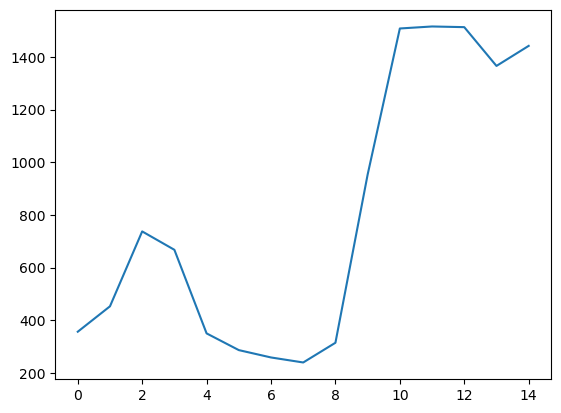

In [12]:
series = X[400]
plt.plot(series)
plt.show()

In [13]:
permutation = np.random.permutation(len(X))

X = X[permutation]
y = y[permutation]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [16]:
X_train_scaled.shape

(319902, 15)

In [17]:
scaler2 = StandardScaler()
y_train_scaled = scaler2.fit_transform(y_train)
y_val_scaled = scaler2.transform(y_val)
y_test_scaled = scaler2.transform(y_test)

# Carga el modelo base de LSTM

In [18]:
# Carga el modelo:
ruta_modelo = "checkpoints/best.keras"

try:
    model = load_model(ruta_modelo)
    print(f"Modelo cargado desde: {ruta_modelo}")
except Exception as e:
    print(f"Error al cargar: Asegúrate de que el archivo exista en la carpeta checkpoints. {e}")

model.summary()

2025-12-22 21:10:21.934430: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-12-22 21:10:21.934551: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-22 21:10:21.934572: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-22 21:10:21.934819: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-22 21:10:21.935132: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Modelo cargado desde: checkpoints/best.keras
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 15, 1)]           0         
                                                                 
 lstm (LSTM)                 (None, 15, 128)           66560     
                                                                 
 dropout (Dropout)           (None, 15, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 7)                 455       
                                                                 
Total params: 11

# Evaluación del modelo base LSTM

In [19]:
y_pred_scaled = model.predict(X_test_scaled, verbose=0)

2025-12-22 21:10:32.722734: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


In [20]:
y_test_scaled.shape

(106634, 7)

In [21]:
# Back to original units (kW)
y_test_orig = scaler2.inverse_transform(y_test_scaled)
y_pred_orig = scaler2.inverse_transform(y_pred_scaled)

In [22]:
def mape(y_true, y_pred, eps=1e-6):
    denom = np.clip(np.abs(y_true), eps, None)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

def smape(y_true, y_pred, eps=1e-6):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.clip(denom, eps, None)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100.0

In [23]:
yt = y_test_orig.reshape(-1)
yp = y_pred_orig.reshape(-1)

In [24]:
metrics = {}
metrics["MAE"] = float(mean_absolute_error(yt, yp))
metrics["RMSE"] = float(math.sqrt(mean_squared_error(yt, yp)))
metrics["MAPE_%"] = float(mape(yt, yp))
metrics["sMAPE_%"] = float(smape(yt, yp))
metrics["R2"] = float(r2_score(yt, yp))

In [25]:
results_df = pd.DataFrame(metrics, index=["LSTM"]).T
results_df

,LSTM
MAE,4.126098e+03
RMSE,3.495511e+04
MAPE_%,7.108995e+09
sMAPE_%,4.853868e+01
R2,9.846851e-01


In [55]:
# Guardamos los resultados de esta evaluacion para poder agregarlos despues al reporte final 

mse_base = metrics["RMSE"]**2

base_row = {
    "Experimento": "0. LSTM Línea Base", 
    "MSE": mse_base,
    "MAE": metrics["MAE"],
    "sMAPE_%": metrics["sMAPE_%"]
}

In [26]:
print(W, H)

15 7


In [27]:
len(X_train)

319902

In [28]:
sample_idx = 1000 
past = X_test[sample_idx]
truth = y_test_orig[sample_idx]
preds = y_pred_orig[sample_idx]

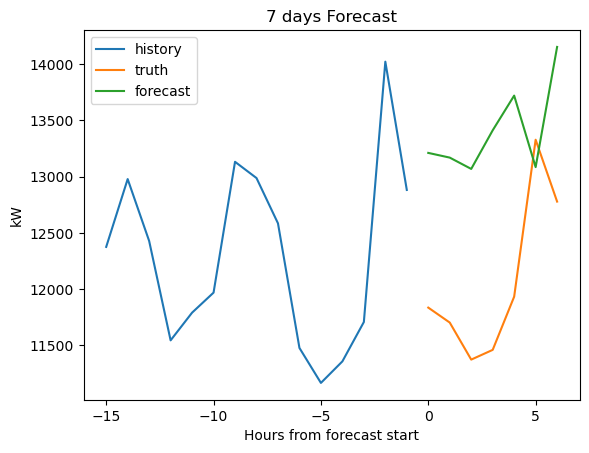

In [29]:
plt.figure()
plt.plot(range(-len(past), 0), past, label="history")
plt.plot(range(0, len(truth)), truth, label="truth")
plt.plot(range(0, len(preds)), preds, label="forecast")
plt.title(f"7 days Forecast")
plt.xlabel("Hours from forecast start")
plt.ylabel("kW")
plt.legend()
plt.show()

In [30]:
sample_idx = 65000 
past = X_test[sample_idx]
truth = y_test_orig[sample_idx]
preds = y_pred_orig[sample_idx]

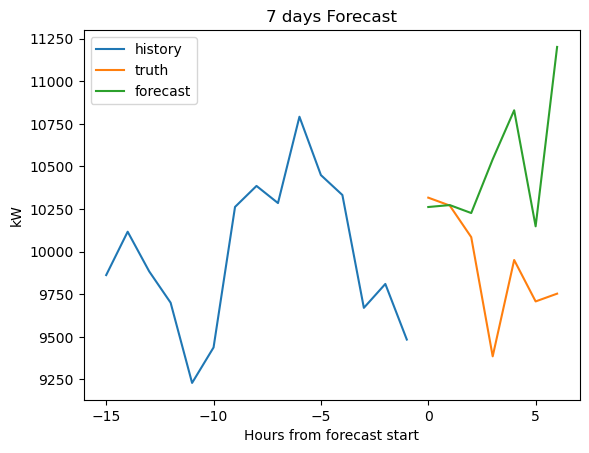

In [31]:
plt.figure()
plt.plot(range(-len(past), 0), past, label="history")
plt.plot(range(0, len(truth)), truth, label="truth")
plt.plot(range(0, len(preds)), preds, label="forecast")
plt.title(f"7 days Forecast")
plt.xlabel("Hours from forecast start")
plt.ylabel("kW")
plt.legend()
plt.show()

# RETO III

In [ ]:
class GradientMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.gradient_norms = []

    def on_epoch_end(self, epoch, logs=None):
        # Tomamos un batch pequeño para calcular el gradiente
        x_batch, y_batch = X_train_scaled[:64], y_train_scaled[:64]
        
        with tf.GradientTape() as tape:
            preds = self.model(x_batch)
            loss = tf.keras.losses.MSE(y_batch, preds)
            
        # Obtenemos gradientes de las capas entrenables
        grads = tape.gradient(loss, self.model.trainable_variables)
        
        # Calculamos la norma global
        norm = tf.linalg.global_norm(grads).numpy()
        self.gradient_norms.append(norm)

# Inicializador I: Glorot Uniform , Orthogonal

In [33]:
def build_model_reto(k_init, r_init):
    inputs = tf.keras.Input(shape=(W, 1))
    # Hiperparámetros 
    x = layers.LSTM(128, return_sequences=True, 
                    kernel_initializer=k_init, 
                    recurrent_initializer=r_init)(inputs)
    x = layers.LSTM(64, kernel_initializer=k_init, 
                    recurrent_initializer=r_init)(x)
    outputs = layers.Dense(H)(x)
    
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

# Creamos la instancia para el primer inicializador
modelo_1 = build_model_reto(k_init='glorot_uniform', r_init='orthogonal')

In [34]:
ckpt_dir = Path("checkpoints")
ckpt_dir.mkdir(exist_ok=True)
path_exp1 = str(ckpt_dir / "best_glorot_ortho.keras")

monitor_1 = GradientMonitor()

callbacks_exp1 = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    tf.keras.callbacks.ModelCheckpoint(path_exp1, save_best_only=True, monitor="val_loss"),
    monitor_1  
]

# 3. Construimos el modelo con el primer inicializador GU, Orthogonal
inputs = tf.keras.Input(shape=(W, 1))
x = tf.keras.layers.LSTM(128, return_sequences=True, 
                         kernel_initializer='glorot_uniform', 
                         recurrent_initializer='orthogonal')(inputs)
x = tf.keras.layers.LSTM(64, 
                         kernel_initializer='glorot_uniform', 
                         recurrent_initializer='orthogonal')(x)
outputs = tf.keras.layers.Dense(H)(x)

model_1 = tf.keras.Model(inputs, outputs)
model_1.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando inicializador 1. Guardando en: {path_exp1}")
history_1 = model_1.fit(
    X_train_scaled, y_train_scaled,
    epochs=50, 
    batch_size=256, 
    validation_data=(X_val_scaled, y_val_scaled),
    callbacks=callbacks_exp1,
    verbose=1
)

Entrenando inicializador 1. Guardando en: checkpoints/best_glorot_ortho.keras
Epoch 1/50
1250/1250 [==============================] - 31s 22ms/step - loss: 0.1409 - val_loss: 0.0510
Epoch 2/50
1250/1250 [==============================] - 23s 19ms/step - loss: 0.0238 - val_loss: 0.0247
Epoch 3/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0178 - val_loss: 0.0172
Epoch 4/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0163 - val_loss: 0.0180
Epoch 5/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0162 - val_loss: 0.0230
Epoch 6/50
1250/1250 [==============================] - 22s 18ms/step - loss: 0.0158 - val_loss: 0.0186
Epoch 7/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0159 - val_loss: 0.0192
Epoch 8/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0160 - val_loss: 0.0185


## Visualizamos la función de pérdida: Inicializador 1 - GU, Orthogonal

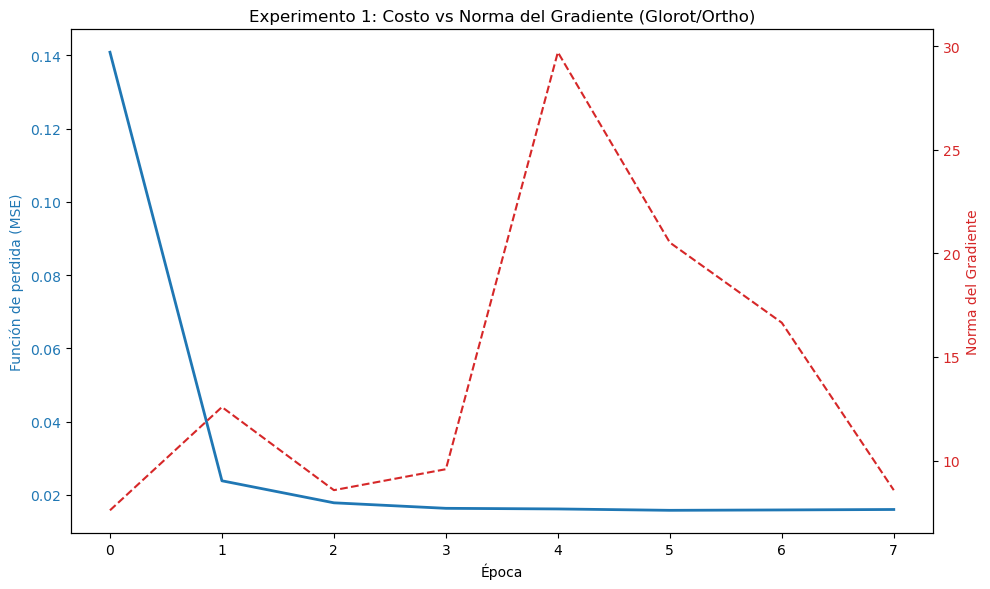

In [35]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gráfica de la función de perdida
ax1.set_xlabel('Época')
ax1.set_ylabel('Función de perdida (MSE)', color='tab:blue')
ax1.plot(history_1.history['loss'], color='tab:blue', label='Costo (Loss)', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Crear un segundo eje para la Norma del Gradiente (Eje Derecho)
ax2 = ax1.twinx()
ax2.set_ylabel('Norma del Gradiente', color='tab:red')
ax2.plot(monitor_1.gradient_norms, color='tab:red', label='Norma Gradiente', linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Experimento 1: Costo vs Norma del Gradiente (Glorot/Ortho)")
fig.tight_layout()
plt.show()

# Inicializador 2 - He normal, He normal:

In [36]:
path_exp2 = str(ckpt_dir / "best_he_normal.keras")

monitor_2 = GradientMonitor()

callbacks_exp2 = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    tf.keras.callbacks.ModelCheckpoint(path_exp2, save_best_only=True, monitor="val_loss"),
    monitor_2 
]

# Modelo con He Normal
inputs = tf.keras.Input(shape=(W, 1))
x = tf.keras.layers.LSTM(128, return_sequences=True, 
                         kernel_initializer='he_normal', 
                         recurrent_initializer='he_normal')(inputs)
x = tf.keras.layers.LSTM(64, 
                         kernel_initializer='he_normal', 
                         recurrent_initializer='he_normal')(x)
outputs = tf.keras.layers.Dense(H)(x)

model_2 = tf.keras.Model(inputs, outputs)
model_2.compile(optimizer='adam', loss='mse')

# Entrenamiento
print(f"Iniciando inicializador 2: He Normal. Guardando en: {path_exp2}")
history_2 = model_2.fit(
    X_train_scaled, y_train_scaled,
    epochs=50, 
    batch_size=256, 
    validation_data=(X_val_scaled, y_val_scaled),
    callbacks=callbacks_exp2,
    verbose=1
)

Iniciando Experimento 2: He Normal. Guardando en: checkpoints/best_he_normal.keras
Epoch 1/50
1250/1250 [==============================] - 25s 19ms/step - loss: 0.1672 - val_loss: 0.0458
Epoch 2/50
1250/1250 [==============================] - 24s 19ms/step - loss: 0.0240 - val_loss: 0.0219
Epoch 3/50
1250/1250 [==============================] - 24s 19ms/step - loss: 0.0174 - val_loss: 0.0186
Epoch 4/50
1250/1250 [==============================] - 23s 19ms/step - loss: 0.0158 - val_loss: 0.0173
Epoch 5/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0157 - val_loss: 0.0169
Epoch 6/50
1250/1250 [==============================] - 24s 19ms/step - loss: 0.0155 - val_loss: 0.0169
Epoch 7/50
1250/1250 [==============================] - 24s 19ms/step - loss: 0.0149 - val_loss: 0.0169
Epoch 8/50
1250/1250 [==============================] - 24s 19ms/step - loss: 0.0150 - val_loss: 0.0171
Epoch 9/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0149 

## Visualizamos la función de pérdida: Inicializador 2 - He normal, He normal

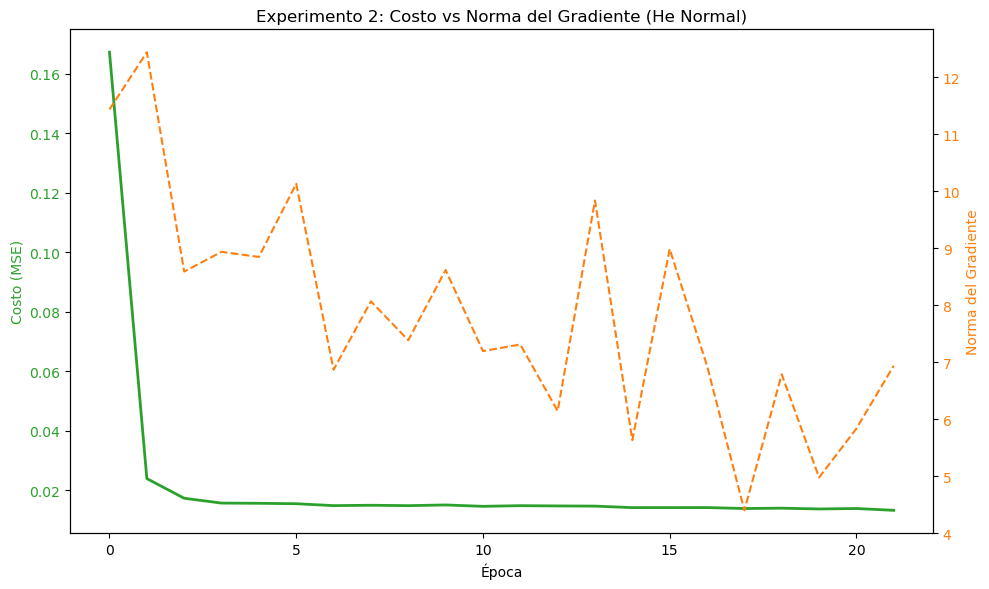

In [37]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Época')
ax1.set_ylabel('Costo (MSE)', color='tab:green')
ax1.plot(history_2.history['loss'], color='tab:green', label='Costo (He Normal)', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:green')

ax2 = ax1.twinx()
ax2.set_ylabel('Norma del Gradiente', color='tab:orange')
ax2.plot(monitor_2.gradient_norms, color='tab:orange', label='Norma Gradiente', linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Experimento 2: Costo vs Norma del Gradiente (He Normal)")
fig.tight_layout()
plt.show()

# Inicializador 3 - Orthogonal, Orthogonal

In [38]:
path_exp3 = str(ckpt_dir / "best_orthogonal.keras")

monitor_3 = GradientMonitor()

callbacks_exp3 = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    tf.keras.callbacks.ModelCheckpoint(path_exp3, save_best_only=True, monitor="val_loss"),
    monitor_3 
]

# Modelo con inicialización Orthogonal
inputs = tf.keras.Input(shape=(W, 1))
x = tf.keras.layers.LSTM(128, return_sequences=True, 
                         kernel_initializer='orthogonal', 
                         recurrent_initializer='orthogonal')(inputs)
x = tf.keras.layers.LSTM(64, 
                         kernel_initializer='orthogonal', 
                         recurrent_initializer='orthogonal')(x)
outputs = tf.keras.layers.Dense(H)(x)

model_3 = tf.keras.Model(inputs, outputs)
model_3.compile(optimizer='adam', loss='mse')

# Entrenamiento
print(f"Iniciando inicializador 3: Orthogonal. Guardando en: {path_exp3}")
history_3 = model_3.fit(
    X_train_scaled, y_train_scaled,
    epochs=50, 
    batch_size=256, 
    validation_data=(X_val_scaled, y_val_scaled),
    callbacks=callbacks_exp3,
    verbose=1
)

Iniciando inicializador 3: Orthogonal. Guardando en: checkpoints/best_orthogonal.keras
Epoch 1/50
1250/1250 [==============================] - 27s 20ms/step - loss: 0.1201 - val_loss: 0.0341
Epoch 2/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0225 - val_loss: 0.0287
Epoch 3/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0184 - val_loss: 0.0184
Epoch 4/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0171 - val_loss: 0.0180
Epoch 5/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0164 - val_loss: 0.0184
Epoch 6/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0163 - val_loss: 0.0176
Epoch 7/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0164 - val_loss: 0.0189
Epoch 8/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0161 - val_loss: 0.0175
Epoch 9/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0

## Visualizamos la función de pérdida: Inicializador 3 - Orthogonal, Orthogonal

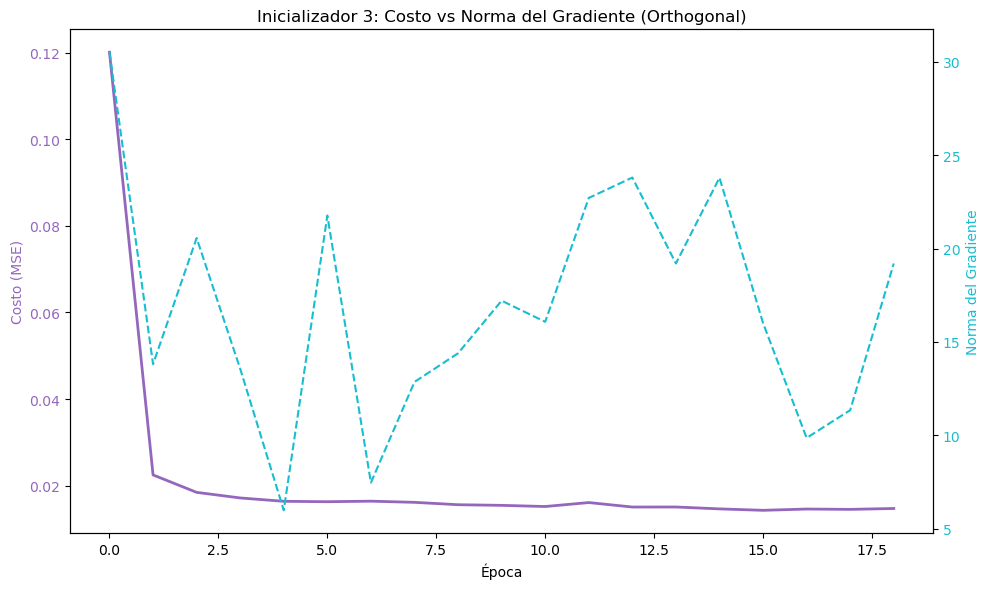

In [39]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Época')
ax1.set_ylabel('Costo (MSE)', color='tab:purple')
ax1.plot(history_3.history['loss'], color='tab:purple', label='Costo (Orthogonal)', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:purple')

ax2 = ax1.twinx()
ax2.set_ylabel('Norma del Gradiente', color='tab:cyan')
ax2.plot(monitor_3.gradient_norms, color='tab:cyan', label='Norma Gradiente', linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:cyan')

plt.title("Inicializador 3: Costo vs Norma del Gradiente (Orthogonal)")
fig.tight_layout()
plt.show()

# Inicializador 4 - RandomNormal (stddev = 0.001)

In [ ]:
path_exp4 = str(ckpt_dir / "best_random_normal.keras")
monitor_4 = GradientMonitor()

# Usamos stddev=0.001 para ver si forzamos el desvanecimiento
vanishing_init = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.001)

callbacks_exp4 = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    tf.keras.callbacks.ModelCheckpoint(path_exp4, save_best_only=True, monitor="val_loss"),
    monitor_4
]

# Construimos el modelo
inputs = tf.keras.Input(shape=(W, 1))
x = tf.keras.layers.LSTM(128, return_sequences=True, 
                         kernel_initializer=vanishing_init, 
                         recurrent_initializer=vanishing_init)(inputs)
x = tf.keras.layers.LSTM(64, 
                         kernel_initializer=vanishing_init, 
                         recurrent_initializer=vanishing_init)(x)
outputs = tf.keras.layers.Dense(H)(x)

model_4 = tf.keras.Model(inputs, outputs)
model_4.compile(optimizer='adam', loss='mse')

# Entrenamiento
print(f"Iniciando inicializador 4: Random Normal (Vanishing). Guardando en: {path_exp4}")
history_4 = model_4.fit(
    X_train_scaled, y_train_scaled,
    epochs=50, 
    batch_size=256, 
    validation_data=(X_val_scaled, y_val_scaled),
    callbacks=callbacks_exp4,
    verbose=1
)

/Users/danielml/miniforge3/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Iniciando inicializador 4: Random Normal (Vanishing). Guardando en: checkpoints/best_random_normal.keras
Epoch 1/50
1250/1250 [==============================] - 26s 19ms/step - loss: 0.1292 - val_loss: 0.0362
Epoch 2/50
1250/1250 [==============================] - 24s 19ms/step - loss: 0.0281 - val_loss: 0.0229
Epoch 3/50
1250/1250 [==============================] - 24s 19ms/step - loss: 0.0180 - val_loss: 0.0187
Epoch 4/50
1250/1250 [==============================] - 24s 19ms/step - loss: 0.0182 - val_loss: 0.0169
Epoch 5/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0176 - val_loss: 0.0189
Epoch 6/50
1250/1250 [==============================] - 23s 19ms/step - loss: 0.0175 - val_loss: 0.0216
Epoch 7/50
1250/1250 [==============================] - 23s 19ms/step - loss: 0.0158 - val_loss: 0.0161
Epoch 8/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0174 - val_loss: 0.0168
Epoch 9/50
1250/1250 [==============================] - 23s 19m

## Visualizamos la función de pérdida: Inicializador 4 - RandomNormal (stddev = 0.001)

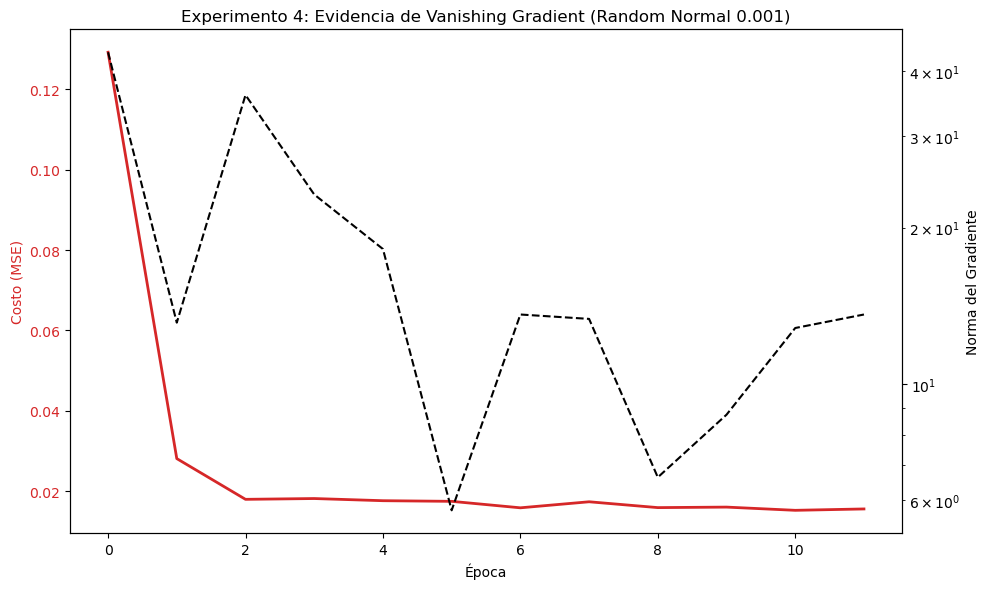

In [41]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Época')
ax1.set_ylabel('Costo (MSE)', color='tab:red')
ax1.plot(history_4.history['loss'], color='tab:red', label='Costo (Random Normal)', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Norma del Gradiente', color='black')
ax2.plot(monitor_4.gradient_norms, color='black', label='Norma Gradiente (Vanishing)', linestyle='--')
# Usamos escala logarítmica aquí porque el valor será muy pequeño
ax2.set_yscale('log') 
ax2.tick_params(axis='y', labelcolor='black')

plt.title("Experimento 4: Evidencia de Vanishing Gradient (Random Normal 0.001)")
fig.tight_layout()
plt.show()

# Inicializador 4.1 - RandomNormal (stddev = 0.2)

In [ ]:
path_exp4_02 = str(ckpt_dir / "best_random_normal_02.keras")

monitor_4_02 = GradientMonitor()

# 3. Inicializador con stddev = 0.2 
random_init_02 = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.2)

callbacks_exp4_02 = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    tf.keras.callbacks.ModelCheckpoint(path_exp4_02, save_best_only=True, monitor="val_loss"),
    monitor_4_02
]

# 4. Modelo
inputs = tf.keras.Input(shape=(W, 1))
x = tf.keras.layers.LSTM(128, return_sequences=True, 
                         kernel_initializer=random_init_02, 
                         recurrent_initializer=random_init_02)(inputs)
x = tf.keras.layers.LSTM(64, 
                         kernel_initializer=random_init_02, 
                         recurrent_initializer=random_init_02)(x)
outputs = tf.keras.layers.Dense(H)(x)

model_4_02 = tf.keras.Model(inputs, outputs)
model_4_02.compile(optimizer='adam', loss='mse')

# 5. Entrenamiento
print(f"Iniciando Experimento 4.1: Random Normal (stddev=0.2). Guardando en: {path_exp4_02}")
history_4_02 = model_4_02.fit(
    X_train_scaled, y_train_scaled,
    epochs=50, 
    batch_size=256, 
    validation_data=(X_val_scaled, y_val_scaled),
    callbacks=callbacks_exp4_02,
    verbose=1
)

Iniciando Experimento 4: Random Normal (stddev=0.2). Guardando en: checkpoints/best_random_normal_02.keras
Epoch 1/50
1250/1250 [==============================] - 25s 19ms/step - loss: 0.1656 - val_loss: 0.0472
Epoch 2/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0263 - val_loss: 0.0312
Epoch 3/50
1250/1250 [==============================] - 22s 18ms/step - loss: 0.0196 - val_loss: 0.0218
Epoch 4/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0170 - val_loss: 0.0191
Epoch 5/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0163 - val_loss: 0.0313
Epoch 6/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0161 - val_loss: 0.0207
Epoch 7/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0153 - val_loss: 0.0180
Epoch 8/50
1250/1250 [==============================] - 23s 18ms/step - loss: 0.0158 - val_loss: 0.0171
Epoch 9/50
1250/1250 [==============================] - 23s 1

## Visualizamos la función de pérdida: Inicializador 4.1 - RandomNormal (stddev = 0.2)

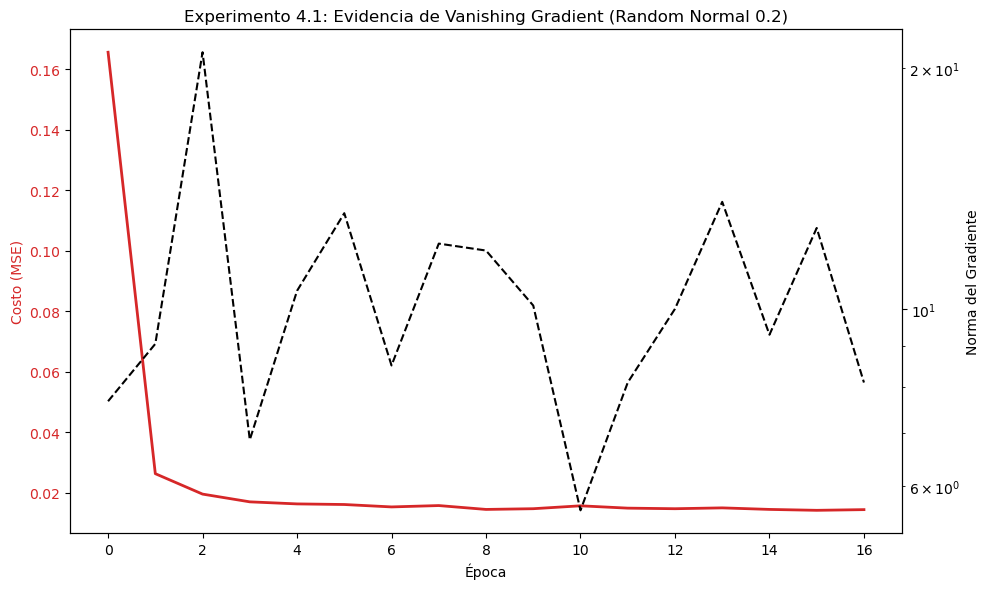

In [49]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Época')
ax1.set_ylabel('Costo (MSE)', color='tab:red')
ax1.plot(history_4_02.history['loss'], color='tab:red', label='Costo (Random Normal)', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Norma del Gradiente', color='black')
ax2.plot(monitor_4_02.gradient_norms, color='black', label='Norma Gradiente (Vanishing)', linestyle='--')

ax2.set_yscale('log') 
ax2.tick_params(axis='y', labelcolor='black')

plt.title("Experimento 4.1: Evidencia de Vanishing Gradient (Random Normal 0.2)")
fig.tight_layout()
plt.show()

# Comparativa global de visualizacion de resultados.

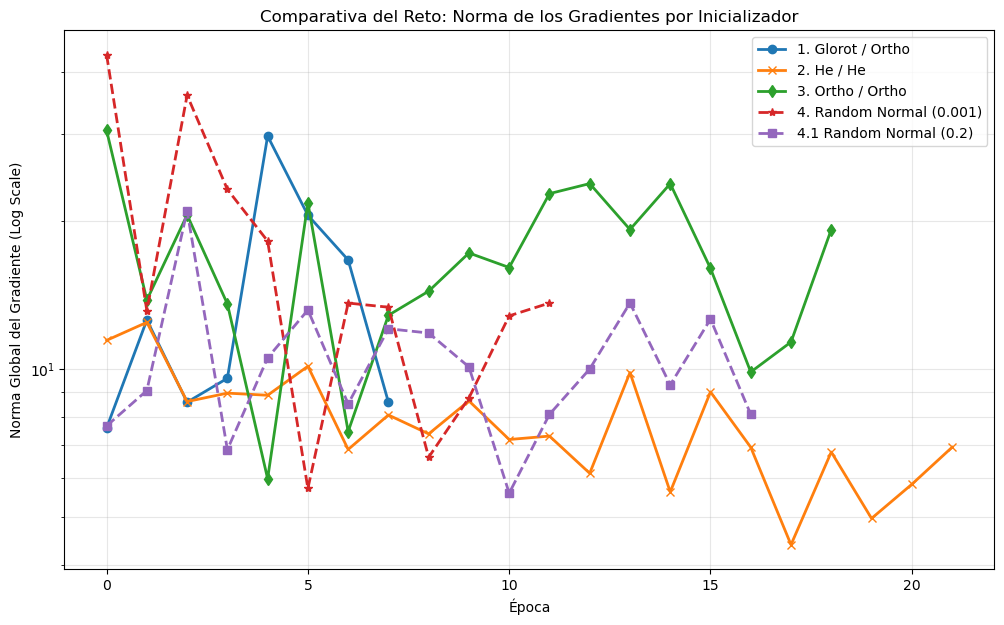

In [50]:
plt.figure(figsize=(12, 7))

# Graficamos las normas recolectadas por cada monitor
plt.plot(monitor_1.gradient_norms, label="1. Glorot / Ortho", linewidth=2, marker='o')
plt.plot(monitor_2.gradient_norms, label="2. He / He", linewidth=2, marker='x')
plt.plot(monitor_3.gradient_norms, label="3. Ortho / Ortho", linewidth=2, marker='d')
plt.plot(monitor_4.gradient_norms, label="4. Random Normal (0.001)", linewidth=2, marker='*', linestyle='--')
plt.plot(monitor_4_02.gradient_norms, label="4.1 Random Normal (0.2)", linewidth=2, marker='s', linestyle='--')

plt.yscale('log') # Escala logarítmica para apreciar diferencias de magnitud
plt.title("Comparativa del Reto: Norma de los Gradientes por Inicializador")
plt.xlabel("Época")
plt.ylabel("Norma Global del Gradiente (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()



# Comparativa de funcion de pérdida | Norma de Gradientes

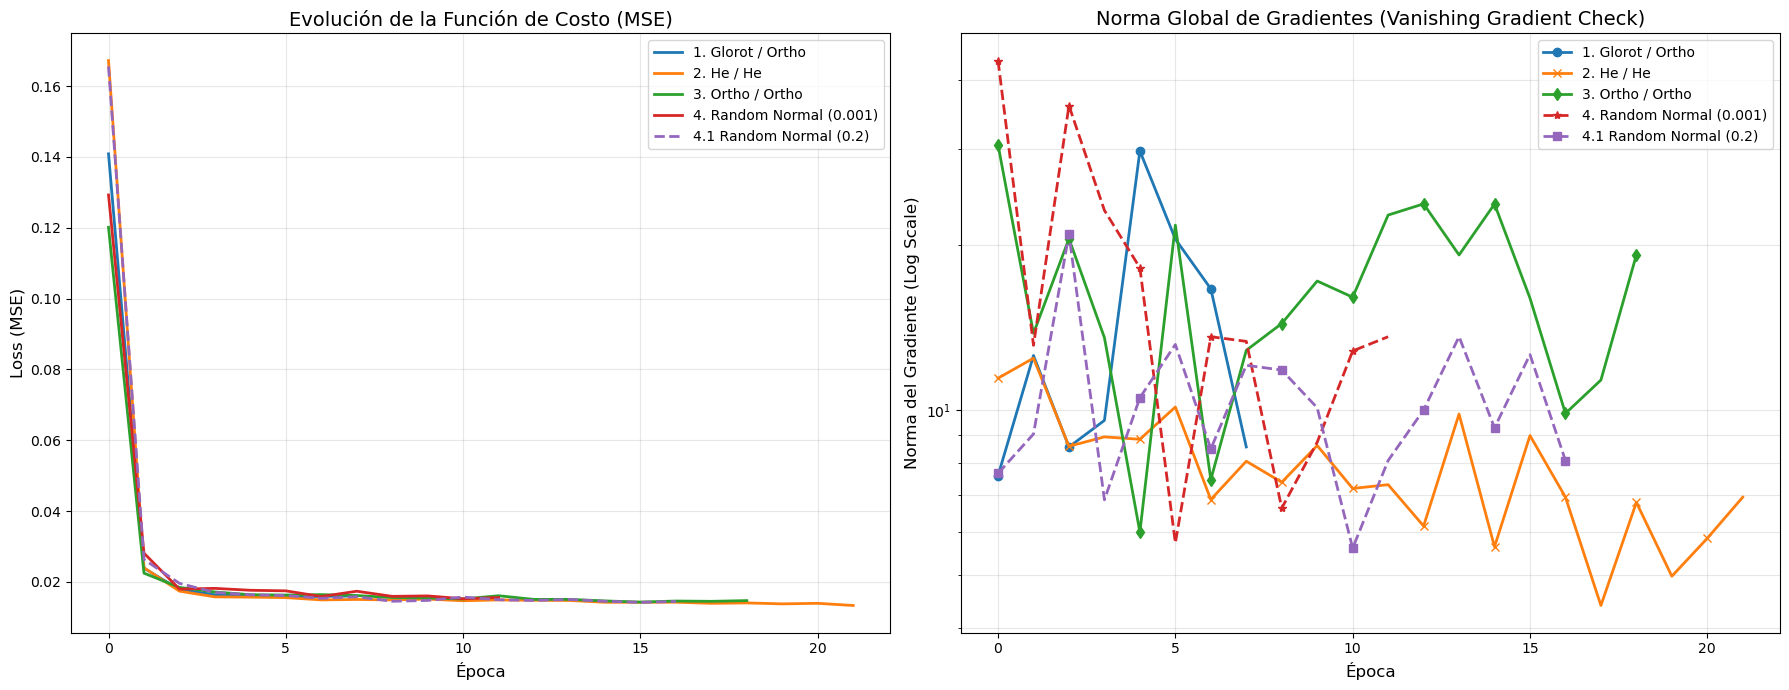

In [ ]:
# Creamos los paneles, (subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- FUNCIÓN DE PERDIDA ---
ax1.plot(history_1.history['loss'], label="1. Glorot / Ortho", linewidth=2)
ax1.plot(history_2.history['loss'], label="2. He / He", linewidth=2)
ax1.plot(history_3.history['loss'], label="3. Ortho / Ortho", linewidth=2)
ax1.plot(history_4.history['loss'], label="4. Random Normal (0.001)", linewidth=2)
ax1.plot(history_4_02.history['loss'], label="4.1 Random Normal (0.2)", linewidth=2, linestyle='--')

ax1.set_title("Evolución de la Función de Costo (MSE)", fontsize=14)
ax1.set_xlabel("Época", fontsize=12)
ax1.set_ylabel("Loss (MSE)", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- NORMA DE LOS GRADIENTES ---
# Aquí es donde demostramos el Vanishing Gradient
ax2.plot(monitor_1.gradient_norms, label="1. Glorot / Ortho", linewidth=2, marker='o', markevery=2)
ax2.plot(monitor_2.gradient_norms, label="2. He / He", linewidth=2, marker='x', markevery=2)
ax2.plot(monitor_3.gradient_norms, label="3. Ortho / Ortho", linewidth=2, marker='d', markevery=2)
plt.plot(monitor_4.gradient_norms, label="4. Random Normal (0.001)", linewidth=2, marker='*', linestyle='--', markevery=2)
ax2.plot(monitor_4_02.gradient_norms, label="4.1 Random Normal (0.2)", linewidth=2, marker='s', linestyle='--', markevery=2)

# Usamos escala logarítmica para detectar si el gradiente se desvanece (tiende a 0)
ax2.set_yscale('log')
ax2.set_title("Norma Global de Gradientes (Vanishing Gradient Check)", fontsize=14)
ax2.set_xlabel("Época", fontsize=12)
ax2.set_ylabel("Norma del Gradiente (Log Scale)", fontsize=12)
ax2.legend()
ax2.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

# Comparativa de métricas en los diferentes modelos y linea base.

In [56]:
modelos_info = {
    "1. Glorot / Ortho": "best_glorot_ortho.keras",
    "2. He / He": "best_he_normal.keras",
    "3. Ortho / Ortho": "best_orthogonal.keras",
    "4. Random Normal (0.001)": "best_random_normal.keras",
    "4.1 Random Normal (0.2)": "best_random_normal_02.keras",
}

resultados = []

for nombre, archivo in modelos_info.items():
    try:
        # Cargamos modelos
        m = load_model(f"checkpoints/{archivo}")
        
        # Realizar las predicciones
        y_pred_scaled = m.predict(X_test_scaled, verbose=0)
        
        # Invertir escalamiento para obtener los kW reales
        y_test_orig = scaler2.inverse_transform(y_test_scaled)
        y_pred_orig = scaler2.inverse_transform(y_pred_scaled)
        
        # Aplanar para el cálculo
        yt = y_test_orig.ravel()
        yp = y_pred_orig.ravel()
        
        # Calcular métricas
        mse_val = np.mean((yt - yp)**2)
        mae_val = np.mean(np.abs(yt - yp))
        smape_val = smape(yt, yp)
        
        resultados.append({
            "Experimento": nombre,
            "MSE": mse_val,
            "MAE": mae_val,
            "sMAPE_%": smape_val
        })
        print(f"✓ {nombre} evaluado con éxito.")
    except Exception as e:
        print(f"✗ Error evaluando {nombre}: {e}")

# Creamos el DataFrame final
df_final = pd.DataFrame(resultados)
df_final = pd.concat([pd.DataFrame([base_row]), df_final], ignore_index=True)
df_final = df_final.set_index("Experimento").sort_values("sMAPE_%")

print("\n--- RESUMEN FINAL DEL RETO ---")
display(df_final)

✓ 1. Glorot / Ortho evaluado con éxito.
✓ 2. He / He evaluado con éxito.
✓ 3. Ortho / Ortho evaluado con éxito.
✓ 4. Random Normal (0.001) evaluado con éxito.
✓ 4.1 Random Normal (0.2) evaluado con éxito.

--- RESUMEN FINAL DEL RETO ---


,MSE,MAE,sMAPE_%
Experimento,,,
4.1 Random Normal (0.2),1.201945e+09,3817.289547,47.935521
0. LSTM Línea Base,1.221860e+09,4126.098364,48.538681
3. Ortho / Ortho,1.176069e+09,3826.605984,49.703396
4. Random Normal (0.001),1.174581e+09,3715.346077,50.203515
2. He / He,1.185617e+09,4192.071862,52.259105
1. Glorot / Ortho,1.372465e+09,4406.964825,53.003987


# Conclusiones.

- Al observar la comparativa de los modelos con sus respectivas metricas, vemos que el experimento con los inicializadores: 

`random_normal: (tf.keras.initializers.RandomNormal(stddev=0.2), tf.keras.initializers.RandomNormal(stddev=0.2))` 

Tuvo un mejor rendimiento con un 47% no muy lejos del modelo de la linea base que se realizó en clase.

- Al observar en el comparativo de graficas de todas las normas del gradiente en los modelos a evaluar podemos observar que:

`Orthogonal, Orthogonal` (linea verde), tuvo una mejor estabilidad lo que podría decirse que es buena "técnica" para frenar el vanishing gradient, sin embargo la precisión del modelo quedo ligeramente por detrás de `random_normal`

- El experimento 1, `glorot_uniform, orthogonal`, es donde quizás podriamos observar con más obviedad el vanishing gradient no solo quizás por su métrica que fue la tuvo un sMAPE más alto, esto es en un 53% , sino que al ver también su gráfica de gradiente tuvo más fluctuaciones y como que no se pudo estabilizar en el aprendizaje